# 🚢 Titanic Survival Analysis — Exploratory Data Analysis

## Project Overview
This project explores the Titanic passenger dataset to understand 
what factors influenced survival rates during the 1912 disaster.

## Dataset
- **Source:** [Kaggle Titanic Dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)
- **Size:** 891 passengers, 12 columns
- **Features:** Age, Gender, Passenger Class, Fare, and more

## Key Findings
1. 💰 **Wealth mattered** — 1st class passengers had the highest survival rate
2. 👩 **Gender was strongest predictor** — 74% of women survived vs 19% of men
3. 👶 **Children were prioritized** — young children had better survival odds
4. 💀 **Worst outcome** — 3rd class males had almost zero chance of survival

## Tools Used
- Python, Pandas, NumPy, Matplotlib, Seaborn

## Author
**Faith Mwende** | [GitHub](https://github.com/Mwende-Fifi)

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [ ]:
# Loading the dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# First look at the data
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

In [27]:
# Understanding the data
print("Column names and data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Column names and data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [28]:
print(type(df['Age'][0]))
print(df['Age'].dtype)

<class 'numpy.float64'>
float64


In [36]:
# Cleaning the data
# Drop Cabin column
# df.drop(columns=['Cabin'], inplace=True)

# # Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# # Fill missing Embarked with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# # Confirm no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [37]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


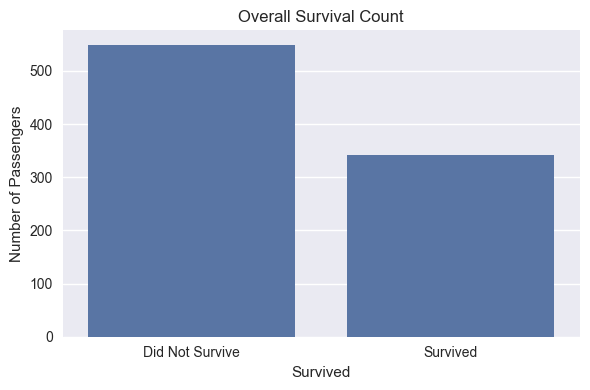

In [38]:
# Overall survival rate
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived')
plt.title('Overall Survival Count')
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

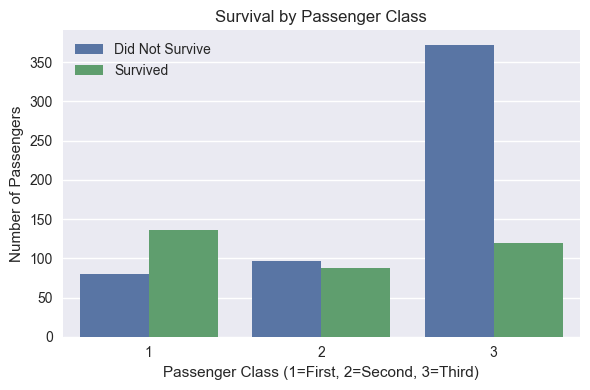

In [39]:
# Survival by passenger class
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Number of Passengers')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()
           

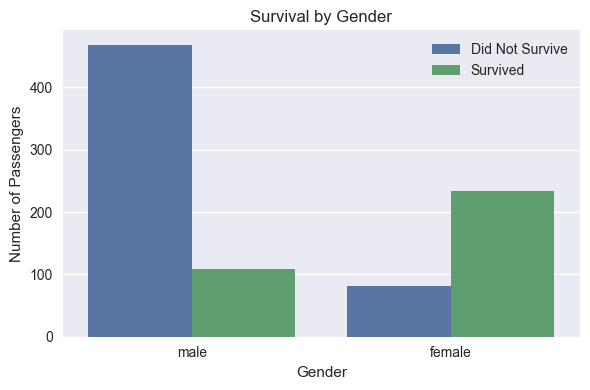

In [40]:
# Survival by gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

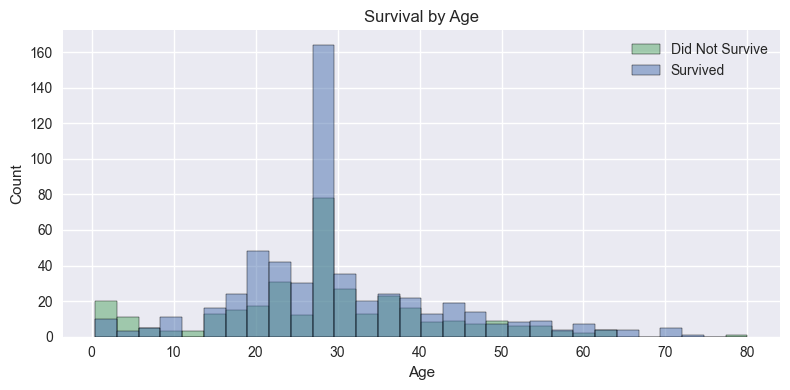

In [41]:
# Survival by age
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30)
plt.title('Survival by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

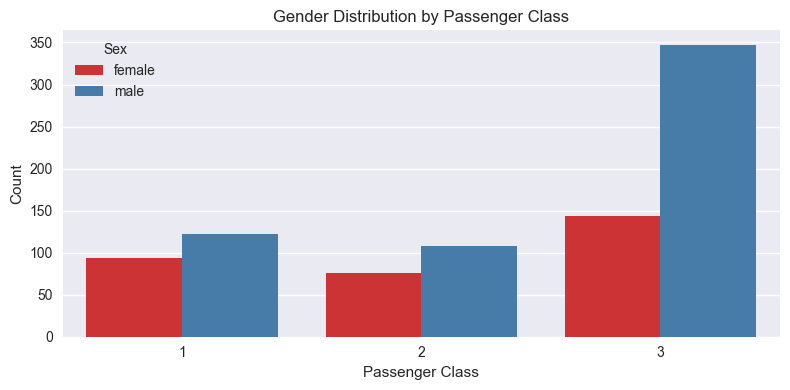

In [42]:
# Survival by class AND gender combined
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Pclass', hue='Sex', palette='Set1')
plt.title('Gender Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

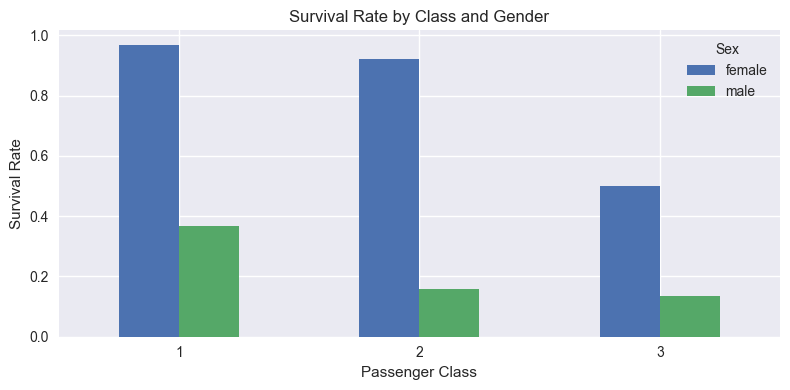

In [43]:
# Survival rate by class and gender
plt.figure(figsize=(8,4))
survival_rate = df.groupby(['Pclass','Sex'])['Survived'].mean().unstack()
survival_rate.plot(kind='bar', figsize=(8,4))
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()